### Section A – BasicExploration

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
sp = pd.read_csv("StudentsPerformance.csv")
sp.head(10)  # the first ten rows

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [3]:
sp.tail(10)  # the last ten rows

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
990,male,group E,high school,free/reduced,completed,86,81,75
991,female,group B,some high school,standard,completed,65,82,78
992,female,group D,associate's degree,free/reduced,none,55,76,76
993,female,group D,bachelor's degree,free/reduced,none,62,72,74
994,male,group A,high school,standard,none,63,63,62
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [4]:
# Check data types of all columns
sp.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
# shape of the dataframe: 8 Columns; 1000 Rows.
sp.shape

(1000, 8)

In [6]:
column_names = sp.columns.tolist()
print(column_names)

['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [7]:
# 1. Identify Categorical Columns
categorical_cols = sp.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:", categorical_cols)

# 2. Identify Numerical Columns
numerical_cols = sp.select_dtypes(include=['number']).columns.tolist()
print("Numerical Columns:", numerical_cols)

Categorical Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
Numerical Columns: ['math score', 'reading score', 'writing score']


In [8]:
sp.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
# Check the count of missing values in each column
print(sp.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


### Section B – Filtering&ConditionalSelection

In [10]:
# Selected students who completed the test preparation course.
print("students who completed the test preparation course:", len(sp[sp['test preparation course'] == 'completed']))

students who completed the test preparation course: 358


In [11]:
# Filter the DataFrame for students with a math score greater than 70
high_math_scores = sp[sp['math score'] > 70]

# students who scored above 70 in maths 
print("Number of students:", high_math_scores.shape[0])

Number of students: 391


In [12]:
# Filter for female students with at least 65 in math, reading, and writing
filtered_students = sp[
    (sp['gender'] == 'female') & 
    (sp['math score'] >= 65) & 
    (sp['reading score'] >= 65) & 
    (sp['writing score'] >= 65)
]

# Display the filtered DataFrame
print(filtered_students)

     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
5    female        group B          associate's degree      standard   
6    female        group B                some college      standard   
..      ...            ...                         ...           ...   
989  female        group D                some college  free/reduced   
991  female        group B            some high school      standard   
995  female        group E             master's degree      standard   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none          72             72         

In [13]:
# Filter and count the number of students with free/reduced lunch
free_lunch_count = sp[sp['lunch'] == 'free/reduced'].shape[0]

print("Number of students with free/reduced lunch:", free_lunch_count)

Number of students with free/reduced lunch: 355


### Section C –GroupBy & Aggregation

In [14]:
# Group by 'gender' and calculate the mean of 'math score'
avg_math_by_gender = sp.groupby('gender')['math score'].mean()

# Display the result
print(avg_math_by_gender)

gender
female    63.633205
male      68.728216
Name: math score, dtype: float64


In [15]:
# Group by parental education and calculate the mean for the score columns
avg_scores_by_education = sp.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean()

# Display the result
print(avg_scores_by_education)

                             math score  reading score  writing score
parental level of education                                          
associate's degree            67.882883      70.927928      69.896396
bachelor's degree             69.389831      73.000000      73.381356
high school                   62.137755      64.704082      62.448980
master's degree               69.745763      75.372881      75.677966
some college                  67.128319      69.460177      68.840708
some high school              63.497207      66.938547      64.888268


In [16]:
# Group by 'test preparation course' and calculate the mean for the score columns
avg_scores_by_prep = sp.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean()

# Display the comparison
print(avg_scores_by_prep)

                         math score  reading score  writing score
test preparation course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673


### Section D – Visualization

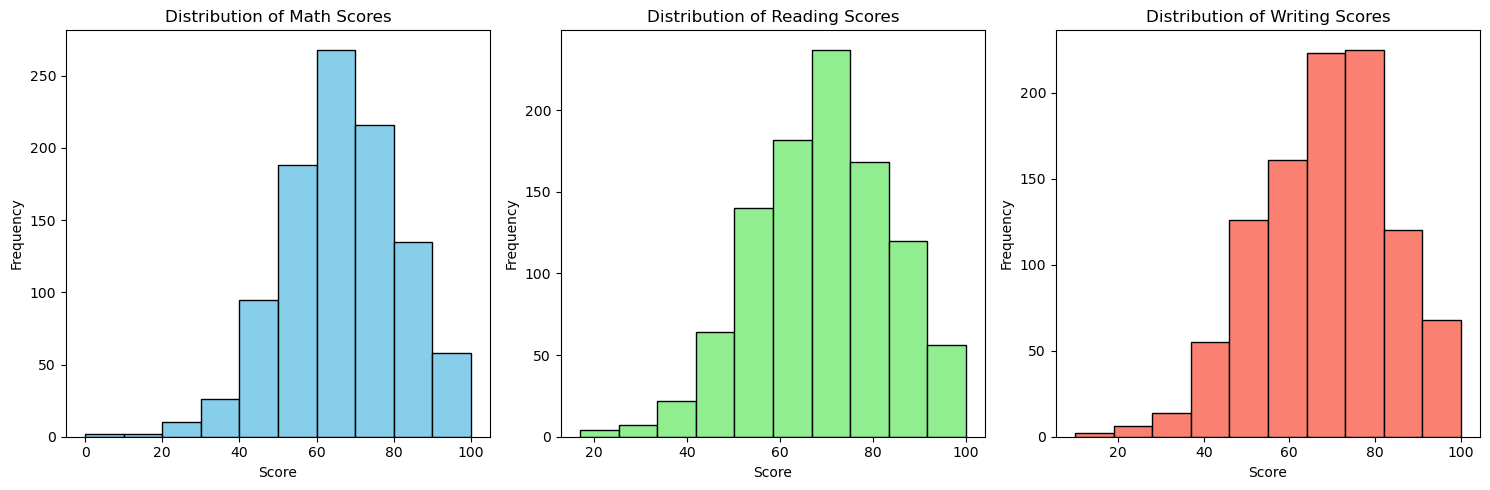

In [17]:
# Set up a figure with a specific size
plt.figure(figsize=(15, 5))

# 1. Math Score Histogram
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
plt.hist(sp['math score'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Math Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')

# 2. Reading Score Histogram
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
plt.hist(sp['reading score'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Distribution of Reading Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')

# 3. Writing Score Histogram
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
plt.hist(sp['writing score'], bins=10, color='salmon', edgecolor='black')
plt.title('Distribution of Writing Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')

# Automatically adjust spacing between plots
plt.tight_layout()

# Display the plots
plt.show()

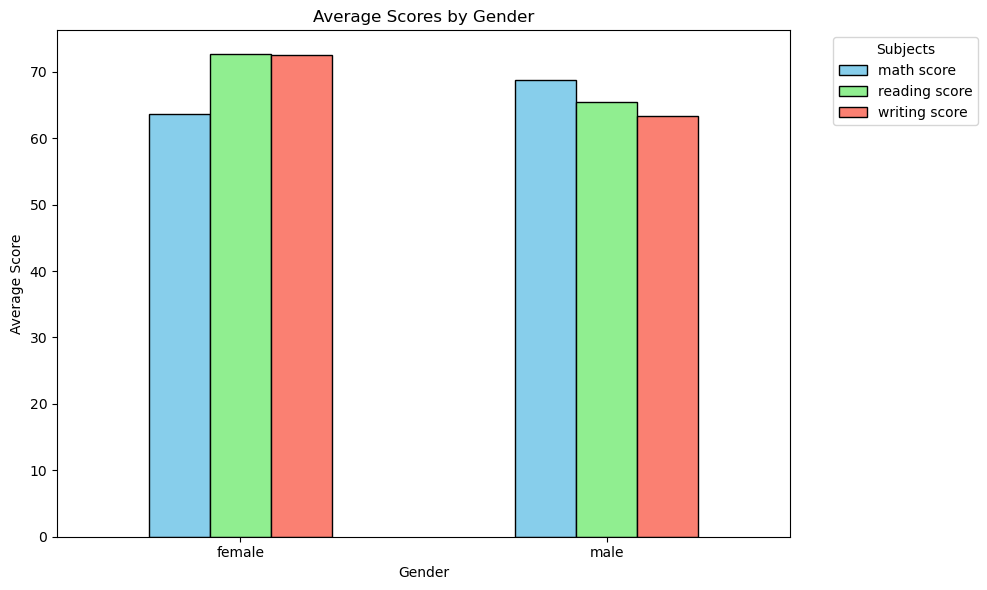

In [18]:
# 1. Calculate the average scores for all subjects grouped by gender
avg_scores_gender = sp.groupby('gender')[['math score', 'reading score', 'writing score']].mean()

# 2. Create the bar plot
# We can call .plot(kind='bar') directly on the grouped DataFrame
avg_scores_gender.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'lightgreen', 'salmon'], edgecolor='black')

# 3. Add the required titles and axis labels
plt.title('Average Scores by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Score')

# 4. Formatting adjustments for a cleaner look
plt.xticks(rotation=0)  # Keeps the 'female' and 'male' labels horizontal
plt.legend(title='Subjects', bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside the bars

# 5. Display the plot
plt.tight_layout()
plt.show()

### Section E – Interpretation

Yes, completing the test preparation course appears to positively improve student performance across the board. When comparing the group averages, students who completed the course consistently achieve higher scores in math, reading, and writing compared to those who had no preparation. This across-the-board increase suggests that the course effectively equips students with the skills or test-taking strategies needed to excel.